In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [12]:
import pandas as pd

df = pd.read_excel(
    r"C:\TOPS\tops-Assignment\Tops-Assignment\Assessment\Supervised Machine Learning\Pharmaceutical Supply Chain Optimization\Pharmaceutical Supply Chain Optimization.xlsx"
)

df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy
0,Metformin,7750,4753,Monthly
1,Lisinopril,5136,9965,Quarterly
2,Metformin,3183,2933,Monthly
3,Insulin,2332,3927,Monthly
4,Atorvastatin,3522,6812,Monthly


In [13]:
df.shape

(100000, 4)

In [14]:
df.columns

Index(['Drug', 'Demand_Forecast', 'Optimal_Stock_Level',
       'Restocking_Strategy'],
      dtype='object')

In [15]:
df.dtypes

Drug                   object
Demand_Forecast         int64
Optimal_Stock_Level     int64
Restocking_Strategy    object
dtype: object

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Drug                 100000 non-null  object
 1   Demand_Forecast      100000 non-null  int64 
 2   Optimal_Stock_Level  100000 non-null  int64 
 3   Restocking_Strategy  100000 non-null  object
dtypes: int64(2), object(2)
memory usage: 3.1+ MB


In [17]:
df.describe()

,Demand_Forecast,Optimal_Stock_Level
count,100000.000000,100000.000000
mean,5489.372180,6270.155320
std,2597.544993,2744.393068
min,1000.000000,1500.000000
25%,3243.000000,3899.750000
50%,5487.000000,6278.000000
75%,7738.000000,8660.000000
max,9999.000000,10999.000000


In [18]:
df.isnull().sum()

Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64

In [19]:
df.duplicated().sum()

5

In [20]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Rows After Removing Duplicates:", len(df))

Duplicate Rows: 5
Rows After Removing Duplicates: 99995


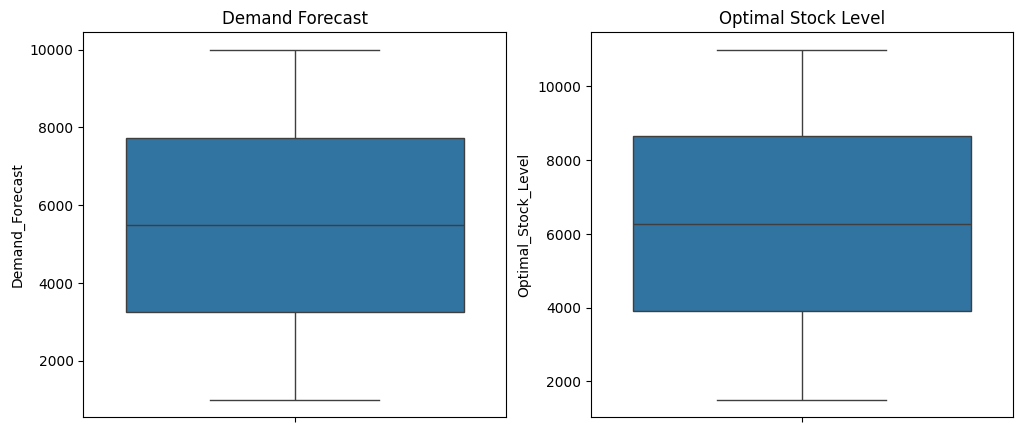

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Demand_Forecast"])
plt.title("Demand Forecast")

plt.subplot(1,2,2)
sns.boxplot(y=df["Optimal_Stock_Level"])
plt.title("Optimal Stock Level")

plt.show()

In [23]:
Q1 = df["Demand_Forecast"].quantile(0.25)
Q3 = df["Demand_Forecast"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Demand_Forecast"] < lower) |
    (df["Demand_Forecast"] > upper)
]

print("Demand Forecast Outliers:", len(outliers))

Demand Forecast Outliers: 0


In [25]:
Q1 = df["Optimal_Stock_Level"].quantile(0.25)
Q3 = df["Optimal_Stock_Level"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Optimal_Stock_Level"] < lower) |
    (df["Optimal_Stock_Level"] > upper)
]

print("Optimal Stock Level Outliers:", len(outliers))

Optimal Stock Level Outliers: 0


perform eda analysis

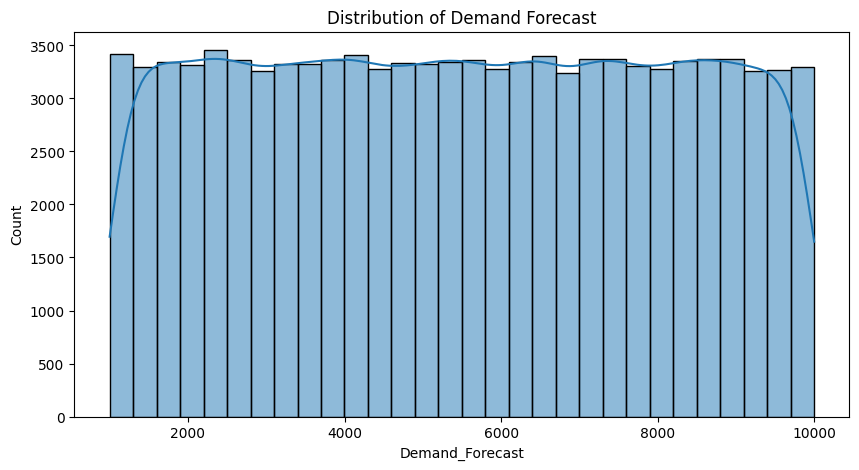

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(df["Demand_Forecast"], bins=30, kde=True)

plt.title("Distribution of Demand Forecast")

plt.show()

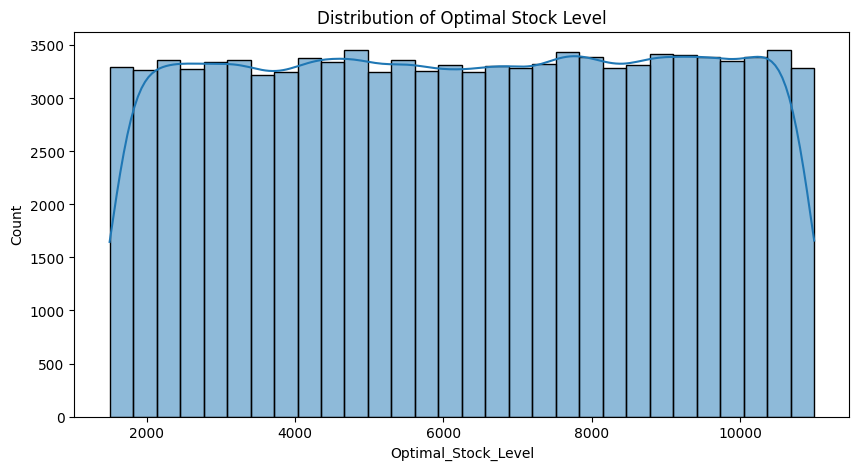

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(df["Optimal_Stock_Level"], bins=30, kde=True)

plt.title("Distribution of Optimal Stock Level")

plt.show()

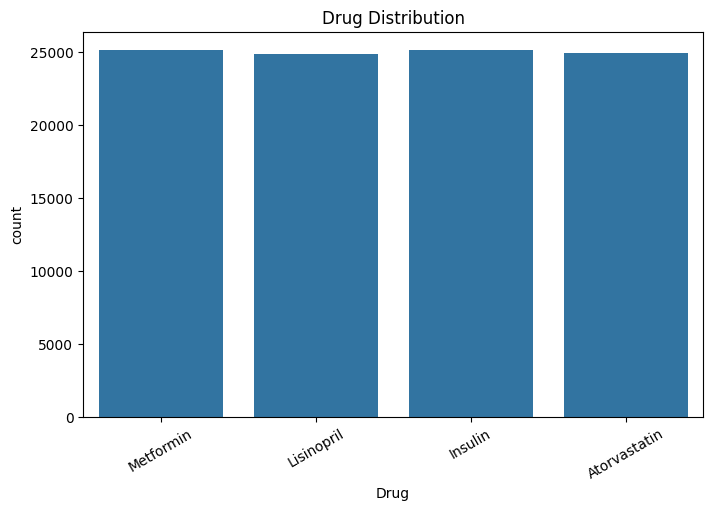

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x="Drug", data=df)

plt.title("Drug Distribution")

plt.xticks(rotation=30)

plt.show()

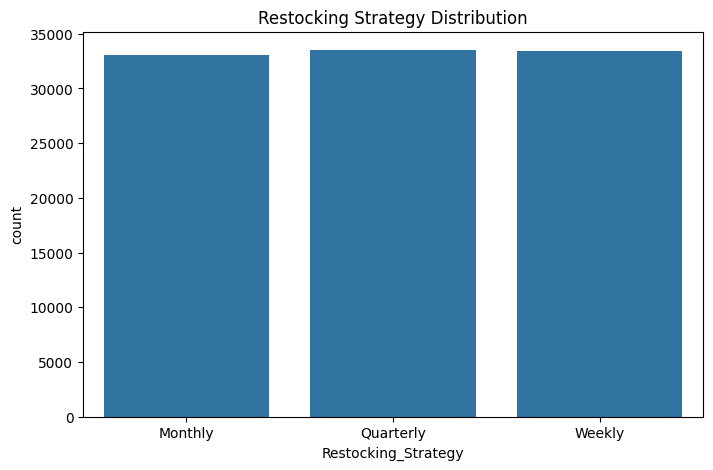

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(x="Restocking_Strategy", data=df)

plt.title("Restocking Strategy Distribution")

plt.show()

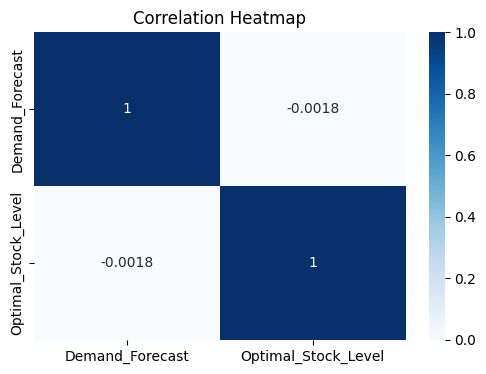

In [32]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["Demand_Forecast", "Optimal_Stock_Level"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

perform engineering


In [33]:
df["Demand_Stock_Ratio"] = (
    df["Demand_Forecast"] /
    df["Optimal_Stock_Level"]
)

df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy,Demand_Stock_Ratio
0,Metformin,7750,4753,Monthly,1.630549
1,Lisinopril,5136,9965,Quarterly,0.515404
2,Metformin,3183,2933,Monthly,1.085237
3,Insulin,2332,3927,Monthly,0.593838
4,Atorvastatin,3522,6812,Monthly,0.517029


In [34]:
df["Demand_Category"] = pd.cut(
    df["Demand_Forecast"],
    bins=[0,3000,6000,10000],
    labels=["Low","Medium","High"]
)

df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy,Demand_Stock_Ratio,Demand_Category
0,Metformin,7750,4753,Monthly,1.630549,High
1,Lisinopril,5136,9965,Quarterly,0.515404,Medium
2,Metformin,3183,2933,Monthly,1.085237,Medium
3,Insulin,2332,3927,Monthly,0.593838,Low
4,Atorvastatin,3522,6812,Monthly,0.517029,Medium


In [35]:
df["Stock_Category"] = pd.cut(
    df["Optimal_Stock_Level"],
    bins=[0,4000,8000,12000],
    labels=["Low","Medium","High"]
)

df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy,Demand_Stock_Ratio,Demand_Category,Stock_Category
0,Metformin,7750,4753,Monthly,1.630549,High,Medium
1,Lisinopril,5136,9965,Quarterly,0.515404,Medium,High
2,Metformin,3183,2933,Monthly,1.085237,Medium,Low
3,Insulin,2332,3927,Monthly,0.593838,Low,Low
4,Atorvastatin,3522,6812,Monthly,0.517029,Medium,Medium


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99995 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Drug                 99995 non-null  object  
 1   Demand_Forecast      99995 non-null  int64   
 2   Optimal_Stock_Level  99995 non-null  int64   
 3   Restocking_Strategy  99995 non-null  object  
 4   Demand_Stock_Ratio   99995 non-null  float64 
 5   Demand_Category      99995 non-null  category
 6   Stock_Category       99995 non-null  category
dtypes: category(2), float64(1), int64(2), object(2)
memory usage: 4.8+ MB


Encode Categorical Variables.

In [37]:
df.dtypes

Drug                     object
Demand_Forecast           int64
Optimal_Stock_Level       int64
Restocking_Strategy      object
Demand_Stock_Ratio      float64
Demand_Category        category
Stock_Category         category
dtype: object

In [38]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Drug"] = label_encoder.fit_transform(df["Drug"])

df["Restocking_Strategy"] = label_encoder.fit_transform(df["Restocking_Strategy"])

df["Demand_Category"] = label_encoder.fit_transform(df["Demand_Category"])

df["Stock_Category"] = label_encoder.fit_transform(df["Stock_Category"])

In [39]:
df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy,Demand_Stock_Ratio,Demand_Category,Stock_Category
0,3,7750,4753,0,1.630549,0,2
1,2,5136,9965,1,0.515404,2,0
2,3,3183,2933,0,1.085237,2,1
3,1,2332,3927,0,0.593838,1,1
4,0,3522,6812,0,0.517029,2,2


In [40]:
df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy,Demand_Stock_Ratio,Demand_Category,Stock_Category
0,3,7750,4753,0,1.630549,0,2
1,2,5136,9965,1,0.515404,2,0
2,3,3183,2933,0,1.085237,2,1
3,1,2332,3927,0,0.593838,1,1
4,0,3522,6812,0,0.517029,2,2


Build a Linear Regression Model

In [41]:
# Features
X = df.drop("Optimal_Stock_Level", axis=1)

# Target
y = df["Optimal_Stock_Level"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [44]:
y_pred_lr = linear_model.predict(X_test)

In [45]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_lr)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("------------------------------")
print("RMSE :", rmse)
print("R² Score :", r2)

Linear Regression Performance
------------------------------
RMSE : 1310.808482385413
R² Score : 0.7711943356811428


Build and Evaluate a Random Forest Regressor.

In [46]:
from sklearn.ensemble import RandomForestRegressor

In [47]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [48]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [49]:
y_pred_rf = rf_model.predict(X_test)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------")
print("RMSE :", rmse_rf)
print("R² Score :", r2_rf)

Random Forest Performance
--------------------------
RMSE : 17.20141002230159
R² Score : 0.9999605981710251


Gradient Boosting Regressor

In [53]:
from sklearn.ensemble import GradientBoostingRegressor

In [54]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

In [55]:
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [56]:
y_pred_gb = gb_model.predict(X_test)

In [57]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_gb = mean_squared_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("------------------------------")
print("RMSE :", rmse_gb)
print("R² Score :", r2_gb)

Gradient Boosting Performance
------------------------------
RMSE : 501.87207719938516
R² Score : 0.9664591277683507


In [58]:
comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "RMSE": [
        rmse,
        rmse_rf,
        rmse_gb
    ],

    "R2 Score": [
        r2,
        r2_rf,
        r2_gb
    ]

})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,1310.808482,0.771194
1,Random Forest,17.201410,0.999961
2,Gradient Boosting,501.872077,0.966459


Hyperparameter Tuning using GridSearchCV.

In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
param_grid = {

    "n_estimators": [50, 100],

    "max_depth": [None, 10, 20],

    "min_samples_split": [2, 5]

}

In [62]:
grid_search = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="neg_mean_squared_error",

    n_jobs=-1

)

In [63]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='neg_mean_squared_error')

In [64]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [65]:
print("Best Score:")
print(grid_search.best_score_)

Best Score:
-381.4504180399695


In [66]:
best_rf = grid_search.best_estimator_

In [67]:
best_predictions = best_rf.predict(X_test)

In [68]:
mse_best = mean_squared_error(y_test, best_predictions)

rmse_best = np.sqrt(mse_best)

r2_best = r2_score(y_test, best_predictions)

print("Optimized Random Forest")
print("-------------------------")
print("RMSE :", rmse_best)
print("R² Score :", r2_best)

Optimized Random Forest
-------------------------
RMSE : 17.20141002230159
R² Score : 0.9999605981710251


Evaluate the Final Model with RMSE and Cross-Validation

In [69]:
print("Final Model Performance")
print("-" * 30)

print(f"RMSE : {rmse_best:.2f}")
print(f"R² Score : {r2_best:.4f}")

Final Model Performance
------------------------------
RMSE : 17.20
R² Score : 1.0000


In [70]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

Cross Validation Scores:
[0.99996122 0.99996285 0.99996189 0.99996018 0.99996169]


In [71]:
print("Average Cross Validation Score:")
print(cv_scores.mean())

Average Cross Validation Score:
0.9999615659275951


In [72]:
final_results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Optimized Random Forest"
    ],

    "RMSE":[
        rmse,
        rmse_rf,
        rmse_gb,
        rmse_best
    ],

    "R² Score":[
        r2,
        r2_rf,
        r2_gb,
        r2_best
    ]

})

final_results

,Model,RMSE,R² Score
0,Linear Regression,1310.808482,0.771194
1,Random Forest,17.201410,0.999961
2,Gradient Boosting,501.872077,0.966459
3,Optimized Random Forest,17.201410,0.999961
